In [ ]:
!pip install datasets==2.19.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [ ]:
import pandas as pd
from datasets import load_dataset

print("=== STEP 1: LOAD & EKSTRAKSI KOLOM SPESIFIK ===")

# 1. Dataset Intanm
print("Loading Intanm...")
ds_intanm = load_dataset("intanm/indonesian-financial-sentiment-analysis")
df_intanm = pd.DataFrame(ds_intanm['train'])
# Kita hanya ambil kolom text dan label
df_intanm = df_intanm[['text', 'label']]

# 2. Dataset Mendeley (Sesuaikan dengan hasil inspeksi Anda)
print("Loading Mendeley...")
ds_mendeley = load_dataset("will702/mendeley-indonesian-stock-sentiment")
df_mendeley = pd.DataFrame(ds_mendeley['train'])
# Rename 'Sentence' -> 'text' dan 'Sentiment' -> 'label'
df_mendeley = df_mendeley.rename(columns={'Sentence': 'text', 'Sentiment': 'label'})
df_mendeley = df_mendeley[['text', 'label']] # Buang kolom lain

# 3. Dataset SmSA Full Version
print("Loading SmSA Full Version...")
ds_smsa = load_dataset("indonlp/indonlu", "smsa", trust_remote_code=True)
df_smsa = pd.concat([
    pd.DataFrame(ds_smsa['train']),
    pd.DataFrame(ds_smsa['validation']),
    pd.DataFrame(ds_smsa['test'])
], ignore_index=True)
# SmSA bawaannya sudah 'text' dan 'label'
df_smsa = df_smsa[['text', 'label']]

# 4. Dataset CNBC (Sesuaikan dengan hasil inspeksi Anda)
print("Loading CNBC...")
path_cnbc = "/content/drive/MyDrive/NLP_Project/cnbc_sentiment.csv"
try:
    df_cnbc = pd.read_csv(path_cnbc)
    # Rename 'judul' -> 'text' dan 'sentimen' -> 'label'
    df_cnbc = df_cnbc.rename(columns={'judul': 'text', 'sentimen': 'label'})
    df_cnbc = df_cnbc[['text', 'label']] # Buang kolom lain
except Exception as e:
    print("Gagal muat CNBC:", e)

print("\n=== STEP 2: PENYERAGAMAN LABEL ===")
# Fungsi kebal huruf besar/kecil
def bersihkan_label(val):
    if pd.isna(val): return None
    val = str(val).lower().strip()

    if val in ['positive', 'positif']:
        return 'Positif'
    elif val in ['negative', 'negatif']:
        return 'Negatif'
    elif val in ['neutral', 'netral']:
        return 'Netral'
    return None

# Bersihkan label di masing-masing dataset
df_intanm['label'] = df_intanm['label'].apply(bersihkan_label)
df_mendeley['label'] = df_mendeley['label'].apply(bersihkan_label)
df_smsa['label'] = df_smsa['label'].apply(bersihkan_label)
df_cnbc['label'] = df_cnbc['label'].apply(bersihkan_label)

print("\n=== STEP 3: PENGGABUNGAN FINAL ===")
# Karena kolomnya sudah sama persis ['text', 'label'], penggabungan akan sempurna
df_train_final = pd.concat([df_intanm, df_mendeley, df_smsa, df_cnbc], ignore_index=True)

# 1. Hapus yang kosong
df_train_final = df_train_final.dropna(subset=['text', 'label'])
print(f"Total Gabungan (SEBELUM hapus duplikat): {len(df_train_final)} baris")

# 2. Hapus duplikat
df_train_final = df_train_final.drop_duplicates(subset=['text'])
print(f"Total Gabungan (SETELAH hapus duplikat): {len(df_train_final)} baris")

print("\n--- DISTRIBUSI LABEL AKHIR ---")
print(df_train_final['label'].value_counts())

=== STEP 1: LOAD & EKSTRAKSI KOLOM SPESIFIK ===
Loading Intanm...
Loading Mendeley...
Loading SmSA Full Version...
Loading CNBC...

=== STEP 2: PENYERAGAMAN LABEL ===

=== STEP 3: PENGGABUNGAN FINAL ===
Total Gabungan (SEBELUM hapus duplikat): 13107 baris
Total Gabungan (SETELAH hapus duplikat): 13001 baris

--- DISTRIBUSI LABEL AKHIR ---
label
Netral     5030
Positif    4633
Negatif    3338
Name: count, dtype: int64


In [ ]:
import pandas as pd
from datasets import load_dataset

print("=== STEP 1: LOAD & EKSTRAKSI KOLOM SPESIFIK ===")

# 1. Intanm (Hanya Train)
print("Loading Intanm...")
df_intanm = pd.DataFrame(load_dataset("intanm/indonesian-financial-sentiment-analysis")['train'])[['text', 'label']]

# 2. Mendeley (Rename Sentence -> text, Sentiment -> label)
print("Loading Mendeley...")
df_mendeley = pd.DataFrame(load_dataset("will702/mendeley-indonesian-stock-sentiment")['train'])
df_mendeley = df_mendeley.rename(columns={'Sentence': 'text', 'Sentiment': 'label'})[['text', 'label']]

# 3. SmSA Full Version (Train + Val + Test)
print("Loading SmSA Full Version...")
ds_smsa = load_dataset("indonlp/indonlu", "smsa", trust_remote_code=True)
df_smsa = pd.concat([pd.DataFrame(ds_smsa[split]) for split in ['train', 'validation', 'test']], ignore_index=True)[['text', 'label']]

# 4. CNBC dari Drive
print("Loading CNBC...")
try:
    path_cnbc = "/content/drive/MyDrive/NLP_Project/cnbc_sentiment.csv"
    df_cnbc = pd.read_csv(path_cnbc).rename(columns={'judul': 'text', 'sentimen': 'label'})[['text', 'label']]
except Exception as e:
    print("Gagal muat CNBC:", e)
    df_cnbc = pd.DataFrame(columns=['text', 'label'])

print("\n=== STEP 2: PENYERAGAMAN LABEL SPESIFIK (ANTI-BOCOR) ===")
# Kita petakan satu-satu sesuai kamus bawaan mereka masing-masing!

# Intanm: 0=Negatif, 1=Netral, 2=Positif
df_intanm['label'] = df_intanm['label'].map({0: 'Negatif', 1: 'Netral', 2: 'Positif'})

# Mendeley: Bahasa Inggris
df_mendeley['label'] = df_mendeley['label'].map({'Positive': 'Positif', 'Neutral': 'Netral', 'Negative': 'Negatif'})

# SmSA: 0=Positif, 1=Netral, 2=Negatif (KEBALIKAN DARI INTANM)
df_smsa['label'] = df_smsa['label'].map({0: 'Positif', 1: 'Netral', 2: 'Negatif'})

# CNBC: Bahasa Indonesia / Huruf Kecil
df_cnbc['label'] = df_cnbc['label'].map({'positif': 'Positif', 'netral': 'Netral', 'negatif': 'Negatif'})

print("\n=== STEP 3: PENGGABUNGAN FINAL ===")
# Gabungkan semuanya
df_train_final = pd.concat([df_intanm, df_mendeley, df_smsa, df_cnbc], ignore_index=True)

# Hapus yang kosong (jika ada yang terlewat)
df_train_final = df_train_final.dropna(subset=['text', 'label'])
print(f"Total Gabungan (SEBELUM hapus duplikat): {len(df_train_final)} baris")

# Hapus kalimat yang persis sama
df_train_final = df_train_final.drop_duplicates(subset=['text'])
print(f"Total Gabungan (SETELAH hapus duplikat): {len(df_train_final)} baris")

print("\n--- DISTRIBUSI LABEL AKHIR ---")
print(df_train_final['label'].value_counts())

=== STEP 1: LOAD & EKSTRAKSI KOLOM SPESIFIK ===
Loading Intanm...
Loading Mendeley...
Loading SmSA Full Version...
Loading CNBC...

=== STEP 2: PENYERAGAMAN LABEL SPESIFIK (ANTI-BOCOR) ===

=== STEP 3: PENGGABUNGAN FINAL ===
Total Gabungan (SEBELUM hapus duplikat): 27189 baris
Total Gabungan (SETELAH hapus duplikat): 26999 baris

--- DISTRIBUSI LABEL AKHIR ---
label
Positif    12589
Negatif     7658
Netral      6752
Name: count, dtype: int64


In [ ]:
import re
import joblib
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

print("=== STEP 4: PREPROCESSING SASTRAWI ===")
slang_dict = {
    "tp": "ambil untung", "cl": "jual rugi", "cuan": "untung",
    "nyangkut": "rugi", "avg": "rata rata", "dyor": "riset sendiri"
}
stemmer = StemmerFactory().create_stemmer()
stopword = StopWordRemoverFactory().create_stop_word_remover()

def bersihkan_teks(text):
    if type(text) != str: return ""
    text = text.lower()
    text = re.sub(r'\$[a-z]+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    text = ' '.join([slang_dict.get(w, w) for w in words])
    text = stopword.remove(text)
    return stemmer.stem(text)

print("⏳ Menjalankan Stemming Sastrawi untuk 26.999 baris... (Silakan ditinggal istirahat dulu)")
df_train_final['clean_text'] = df_train_final['text'].apply(bersihkan_teks)

print("\n=== STEP 5: SIMPAN DATA BERSIH KE DRIVE ===")
path_bersih = "/content/drive/MyDrive/NLP_Project/df_train_master_cleaned.csv"
df_train_final.to_csv(path_bersih, index=False)
print(f"✅ Data bersih aman tersimpan di: {path_bersih}")

print("\n=== STEP 6: EKSTRAKSI FITUR (TF-IDF) ===")
X_train = df_train_final['clean_text']
y_train = df_train_final['label']

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
print(f"Matriks TF-IDF selesai dibuat. Total kosa kata unik: {X_train_tfidf.shape[1]}")

print("\n=== STEP 7: TRAINING MODEL BASELINE ===")
print("Melatih Support Vector Machine (SVM)...")
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

print("Melatih Random Forest (RF)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

print("\n=== STEP 8: SIMPAN MODEL ===")
path_model = "/content/drive/MyDrive/NLP_Project/"
joblib.dump(vectorizer, path_model + 'tfidf_vectorizer_master.pkl')
joblib.dump(svm_model, path_model + 'svm_model_master.pkl')
joblib.dump(rf_model, path_model + 'rf_model_master.pkl')

print("🎉 SEMUA SELESAI! Model siap digunakan untuk proses evaluasi akhir.")

=== STEP 4: PREPROCESSING SASTRAWI ===
⏳ Menjalankan Stemming Sastrawi untuk 26.999 baris... (Silakan ditinggal istirahat dulu)

=== STEP 5: SIMPAN DATA BERSIH KE DRIVE ===
✅ Data bersih aman tersimpan di: /content/drive/MyDrive/NLP_Project/df_train_master_cleaned.csv

=== STEP 6: EKSTRAKSI FITUR (TF-IDF) ===
Matriks TF-IDF selesai dibuat. Total kosa kata unik: 18417

=== STEP 7: TRAINING MODEL BASELINE ===
Melatih Support Vector Machine (SVM)...
Melatih Random Forest (RF)...

=== STEP 8: SIMPAN MODEL ===
🎉 SEMUA SELESAI! Model siap digunakan untuk proses evaluasi akhir.


=== STEP 1: PENGGABUNGAN 5.000 DATA UJI (VERSI REVISI NAMA) ===
✅ Berhasil memuat: INET_labeled.csv (1000 baris)
✅ Berhasil memuat: DEWA_labeled.csv (1000 baris)
✅ Berhasil memuat: AADI_labeled.csv (1000 baris)
✅ Berhasil memuat: BUMI_labeled.csv (1000 baris)
✅ Berhasil memuat: ELSA_labeled.csv (1000 baris)

➡️ Total Data Ujian Nasional Terkumpul: 4997 baris

=== STEP 2: LOAD MODEL & PREPROCESSING ===
✅ Semua model baseline berhasil dimuat!

=== STEP 3: EVALUASI SUPPORT VECTOR MACHINE (SVM) ===
              precision    recall  f1-score   support

     Negatif       0.41      0.62      0.49      1261
      Netral       0.37      0.41      0.39      1360
     Positif       0.64      0.42      0.51      2376

    accuracy                           0.47      4997
   macro avg       0.47      0.48      0.46      4997
weighted avg       0.51      0.47      0.47      4997


=== STEP 4: EVALUASI RANDOM FOREST (RF) ===
              precision    recall  f1-score   support

     Negatif       

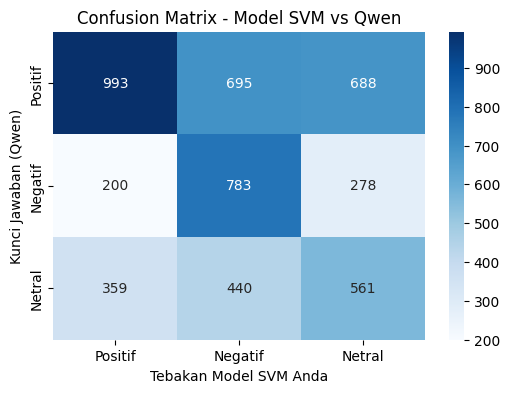

In [2]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== STEP 1: PENGGABUNGAN 5.000 DATA UJI (VERSI REVISI NAMA) ===")
# Daftar nama file sesuai format EMITEN_final
file_names = ['INET_labeled.csv', 'DEWA_labeled.csv', 'AADI_labeled.csv', 'BUMI_labeled.csv', 'ELSA_labeled.csv']

# Sesuaikan dengan lokasi folder NLP_qwen Anda di Drive
path_folder = "/content/drive/MyDrive/NLP_qwen/"
# Catatan: Jika NLP_qwen ada di dalam folder NLP_Project, ganti menjadi:
# path_folder = "/content/drive/MyDrive/NLP_Project/NLP_qwen/"

list_df = []
for file in file_names:
    try:
        full_path = path_folder + file
        df_temp = pd.read_csv(full_path)

        # Jaga-jaga jika nama kolom teks hasil scraping Anda bernama 'content' atau 'text'
        # Kita seragamkan menjadi 'text' agar proses TF-IDF berjalan lancar
        if 'content' in df_temp.columns and 'text' not in df_temp.columns:
            df_temp = df_temp.rename(columns={'content': 'text'})

        list_df.append(df_temp)
        print(f"✅ Berhasil memuat: {file} ({len(df_temp)} baris)")
    except Exception as e:
        print(f"❌ Gagal memuat {file}. Periksa apakah path sudah benar. Error: {e}")

# Gabungkan seluruh emiten menjadi satu kesatuan Data Uji
df_test = pd.concat(list_df, ignore_index=True)
df_test = df_test.dropna(subset=['text', 'label'])
print(f"\n➡️ Total Data Ujian Nasional Terkumpul: {len(df_test)} baris")

print("\n=== STEP 2: LOAD MODEL & PREPROCESSING ===")
# Mengambil TF-IDF Vectorizer dan Model SVM/RF dari folder project sebelumnya
# Sesuaikan path_model jika Anda menyimpannya di folder yang berbeda
path_model = "/content/drive/MyDrive/NLP_Project/"

try:
    vectorizer = joblib.load(path_model + 'tfidf_vectorizer_master.pkl')
    svm_model = joblib.load(path_model + 'svm_model_master.pkl')
    rf_model = joblib.load(path_model + 'rf_model_master.pkl')
    print("✅ Semua model baseline berhasil dimuat!")
except Exception as e:
    print(f"❌ Gagal memuat model. Periksa lokasi pkl Anda. Error: {e}")

# Transformasi teks ujian menjadi matriks TF-IDF
X_test_tfidf = vectorizer.transform(df_test['text'].astype(str))
y_test_asli = df_test['label'] # Kunci jawaban (Ground Truth) dari Qwen

print("\n=== STEP 3: EVALUASI SUPPORT VECTOR MACHINE (SVM) ===")
y_pred_svm = svm_model.predict(X_test_tfidf)
print(classification_report(y_test_asli, y_pred_svm))

print("\n=== STEP 4: EVALUASI RANDOM FOREST (RF) ===")
y_pred_rf = rf_model.predict(X_test_tfidf)
print(classification_report(y_test_asli, y_pred_rf))

print("\n=== VISUALISASI CONFUSION MATRIX (SVM) ===")
cm = confusion_matrix(y_test_asli, y_pred_svm, labels=["Positif", "Negatif", "Netral"])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Positif", "Negatif", "Netral"],
            yticklabels=["Positif", "Negatif", "Netral"])
plt.ylabel('Kunci Jawaban (Qwen)')
plt.xlabel('Tebakan Model SVM')
plt.title('Confusion Matrix - Model SVM vs Qwen')
plt.show()


=== VISUALISASI CONFUSION MATRIX (RF) ===


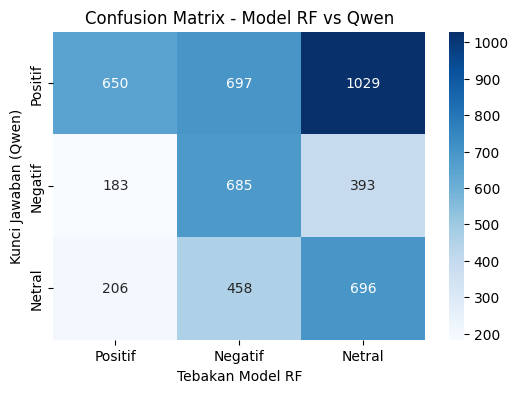

In [3]:
print("\n=== VISUALISASI CONFUSION MATRIX (RF) ===")
cm = confusion_matrix(y_test_asli, y_pred_rf, labels=["Positif", "Negatif", "Netral"])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Positif", "Negatif", "Netral"],
            yticklabels=["Positif", "Negatif", "Netral"])
plt.ylabel('Kunci Jawaban (Qwen)')
plt.xlabel('Tebakan Model RF')
plt.title('Confusion Matrix - Model RF vs Qwen')
plt.show()